Critical Chi-Square Value: 3.841458820694124


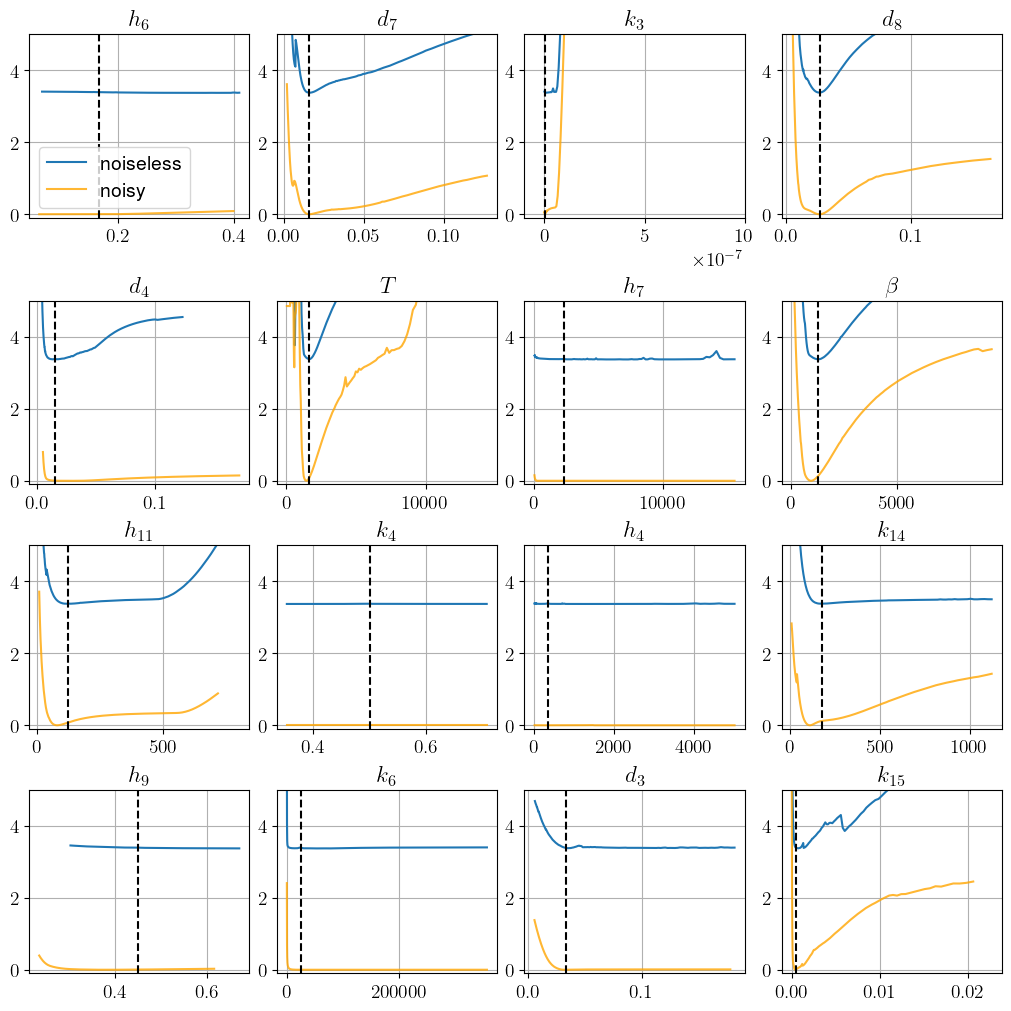

In [9]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from ITIS_Model_funcs import ITIS, ITIS_modelcall, get_nominal_param
from scipy.integrate import odeint

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14,
    'figure.constrained_layout.use' : True,
    'savefig.dpi' : 600
})

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'\u03B1', 'k', '\u03B2', 'L', '\u03B5', '\u03B4', 'T', 'Nc']

param_titles_latex = [
    r'$d_1$',
    r'$k_1$', r'$k_2$', r'$h_1$', r'$h_2$', r'$h_3$', r'$d_2$',
    r'$k_3$', r'$k_4$', r'$h_4$', r'$d_3$',
    r'$h_5$', r'$h_6$', r'$k_5$', r'$k_6$', r'$h_7$', r'$d_4$',
    r'$b_1$', r'$k_7$', r'$h_8$', r'$k_8$', r'$h_9$', r'$d_5$', r'$h_{10}$',
    r'$b_2$', r'$k_9$', r'$k_{10}$', r'$k_{11}$', r'$d_6$',
    r'$k_{12}$', r'$k_{13}$', r'$k_{14}$', r'$h_{11}$', r'$d_7$',
    r'$k_{15}$', r'$k_{16}$', r'$d_8$',
    r'$\alpha$', r'$k$', r'$\beta$', r'$L$', r'$\epsilon$', r'$\delta$', r'$T$', r'$N_c$'
]

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

D = '3'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13

N = 'noisy'   #'noisy' or 'nonoise'. Not perfect, some paths may need to be tweaked.

partitle = 'k3' #Will err if parameter is not in param_ids. Should match title in param_titles (so alpha would be '\u03B1')

if D == '1':
    output_ids = [6,7]
elif D == '2':
    output_ids = [3,6,7]
else:
    output_ids = [3,4,6,7]

if N == 'noisy':
    with open('PL_results_V3\\PL_' + D + dpoints + 'noisy.pkl', 'rb') as f:
        results1 = pickle.load(f)


    # all_results = {
    #     'param_ids' : param_ids,
    #     't_data' : t_data,
    #     'y_data' : y_data,
    #     'true_sol' : true_sol,
    #     'J_save': J_save,
    #     'par_save': par_save,
    #     'param_global_all': param_global_all
    # }
    #

    param_ids1 = results1['param_ids']
    t_data1 = results1['t_data']
    y_data1 = results1['y_data']
    true_sol1 = results1['true_sol']
    J_save1 = results1['J_save'].copy()
    par_save1 = results1['par_save'].copy()
    param_global_all1 = results1['param_global_all']

    with open('PL_Results_V3\\PL_' + D + dpoints + 'nonoise.pkl', 'rb') as f:
        results2 = pickle.load(f)

    param_ids2 = results2['param_ids']
    t_data2 = results2['t_data']
    y_data2 = results2['y_data']
    true_sol2 = results2['true_sol']
    J_save2 = results2['J_save'].copy()
    par_save2 = results2['par_save'].copy()
    param_global_all2 = results2['param_global_all']

elif N == 'nonoise':
    with open('PL_results_V3\\PL_' + D + dpoints + 'nonoise.pkl', 'rb') as f:
        results1 = pickle.load(f)

    param_ids1 = results1['param_ids']
    t_data1 = results1['t_data']
    y_data1 = results1['y_data']
    true_sol1 = results1['true_sol']
    J_save1 = results1['J_save'].copy()
    par_save1 = results1['par_save'].copy()
    param_global_all1 = results1['param_global_all']

    with open('PL_Results_V3\\PL_' + D + dpoints + 'noisy.pkl', 'rb') as f:
        results2 = pickle.load(f)

    param_ids2 = results2['param_ids']
    t_data2 = results2['t_data']
    y_data2 = results2['y_data']
    true_sol2 = results2['true_sol']
    J_save2 = results2['J_save'].copy()
    par_save2 = results2['par_save'].copy()
    param_global_all2 = results2['param_global_all']

from scipy.stats import chi2
#
alpha = 0.05  # Significance level
df = 1        # Degrees of freedom

# Calculate the critical value
critical_value = chi2.ppf(1 - alpha, df)

print(f"Critical Chi-Square Value: {critical_value}")

# for i in range(len(param_ids)):
#
#     plt.figure()
#     plt.title(paramtitles[param_ids[i]])
#     plt.plot(par_save[i,i,:],J_save[i,:])
#     plt.axhline(y=critical_value, color='r')
#     plt.show()

if param_ids1 != param_ids2:
    print("PARAM ORDER DOES NOT MATCH")

fig, axs = plt.subplots(4,4, figsize = (10,10))
CI = np.zeros((20,2))
for i in range(4):

    for k in range(4):
        if i*4 + k>= len(param_ids1):
            for r in range(k,4):
                axs[i,r].remove()
            break
        axs[i,k].set_ylim(-0.1,5)
        if param_titles[param_ids1[i*4+k]] == 'k3':
            axs[i,k].set_xlim(left = -1e-7, right = 1e-6)
        # if i*4 + k == 9:
        #     with open('PL_results_V3\\PL_alpha_' + D + dpoints + 'noisy.pkl', 'rb') as f:
        #         a_results = pickle.load(f)
        #
        #     a_param_ids = a_results['param_ids']
        #     a_t_data = a_results['t_data']
        #     a_y_data = a_results['y_data']
        #     a_true_sol = a_results['true_sol']
        #     a_J_save = a_results['J_save'].copy()
        #     a_par_save = a_results['par_save'].copy()
        #     a_param_global_all = a_results['param_global_all']
        #
        #     axs[i, k].plot(np.exp(a_par_save[i*4 + k, i*4 +k,:]),a_J_save[i*4 +k,:] - min(a_J_save[i*4+k,:]), label = "noisy", color = 'orange')
        #     axs[i, k].plot(np.exp(par_save1[i*4 + k, i*4 +k,:]),J_save1[i*4 + k,:], label = "noiseless")
        #     #axs[i, k].axhline(y=critical_value+np.min(a_J_save[i*4 +k,:]), color='orange', linestyle='--')
        #     axs[i, k].axhline(y=critical_value+np.min(J_save1[i*4 + k,:]), linestyle='--', color = 'gray')
        #     axs[i,k].set_title(param_titles_latex[param_ids1[i*4 + k]])
        #     axs[i,k].axvline(x = np.exp(param_global_all1[i*4+k]), linestyle='--', color = 'k')
        # else:
        axs[i, k].plot(np.exp(par_save1[i*4 + k, i*4 +k,:]),J_save1[i*4 + k,:], label = "noiseless")
        axs[i, k].plot(np.exp(par_save2[i*4 + k, i*4 +k,:]),J_save2[i*4 + k,:] - min(J_save2[i*4+k,:]), label = "noisy", color = 'orange', alpha = .8)
        axs[i, k].axhline(y=critical_value+np.min(J_save1[i*4 + k,:]), linestyle='--', color = 'gray')
        #axs[i, k].axhline(y=critical_value+np.min(J_save2[i*4 + k,:]), color='orange', linestyle='--')
        axs[i,k].set_title(param_titles_latex[param_ids1[i*4 + k]])
        axs[i,k].axvline(x = np.exp(param_global_all1[i*4 + k]), linestyle='--', color = 'k')
        axs[i,k].grid(zorder=.5)
        #axs[i,k].axvline(x = np.exp(param_global_all2[i*4 + k]), color = 'orange', linestyle = '--')
# for ax in axs.flat:
#     ax.set_xticks([])
#fig.tight_layout()
axs[0,0].legend()
#fig.savefig('epsFigs\\PLCurves\\PL_Overlap' + D + dpoints + '.pdf')

##ADD CI FROM GLOBAL OPT TO THESE RESULTS

output_obs = output_ids.copy()

Observed states: ['TNF-α', 'IL10', 'ACTH', 'Cortisol']
Plotted states (in order shown): ['TNF-α', 'IL10', 'ACTH', 'Cortisol']


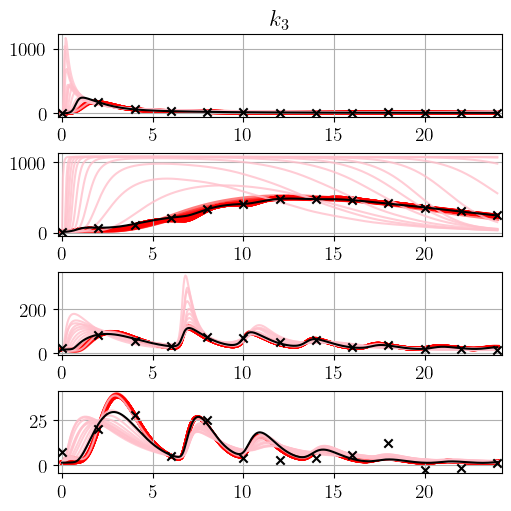

In [10]:
from matplotlib.lines import Line2D
print("Observed states:", [stateTitles[i] for i in output_ids])

output_ids = [3,4,6,7]

obs_bool = [any(x==output_ids[i] for x in output_obs) for i in range(len(output_ids))]

print("Plotted states (in order shown):",[stateTitles[i] for i in output_ids])
param_log, IC = get_nominal_param()
dt = .05
t_data = np.arange(0,24+dt,dt)
par = param_ids1.index(param_titles.index(partitle)) #Can also manually set this to an index, going by location in the graph matrix (NOT by param_titles)
true_sol = ITIS_modelcall(param_log[0],t_data,0,output_ids,param_log,IC)
n_states = 0


for j in range(1):#(len(param_ids1)): ##Can be expanded to run all identifiable param
    fig, axs = plt.subplots(len(output_ids), figsize = (5,5))
    for k in range(len(output_ids)): #CHANGE TO ALWAYS HAVE ALL Loop through each model state for given design
        #axs[k].plot(t_data, true_sol[:,k], color = 'black', label = 'True sol')
        axs[k].margins(x=.01)
        axs[k].grid(zorder = .5)
        for i in range(0,200,5): #Plot all 200 parameter value solutions
            param_in = par_save1[par,:,i]
            par_id = param_ids1[par]
            sol = ITIS_modelcall(param_in,t_data, param_ids1,output_ids,param_log,IC)

            #NEED TO LOOK INTO HOW CIS CALCULATED. VALUES NOT AGREEING RN
            if J_save1[par,i] < critical_value+np.min(J_save1[par,:]):
                axs[k].plot(t_data,sol[:,k], color = 'red', lw = 3, alpha = .5, zorder = 1)
            # elif param_global_all2[par] - 5*half_width[par] < param_in < param_global_all2[par] + 5*half_width[par]:
            #     axs[k].plot(t_data,sol[:,k], color = 'red', alpha = 0.2)
            else:
                axs[k].plot(t_data,sol[:,k], color = 'pink', lw = 1.5, zorder = 2, alpha = .8)

        if obs_bool[k]:
            axs[k].scatter(t_data1,y_data1[:,n_states], marker = 'x', color = 'k', zorder = 3)
            n_states += 1
        opt_sol = ITIS_modelcall(param_global_all1[par],t_data, param_ids1[par],output_ids,param_log,IC)


        # bound_u = ITIS_modelcall(param_global_all1[par] + half_width[par],t_data, param_ids1[par],output_ids,param_log,IC)
        # axs[k].plot(t_data, bound_l[:,k], color = 'cyan', label = 'Upper bound')

        axs[k].plot(t_data,true_sol[:,k], color = 'k', label = 'True Sol', zorder = 3)

        # bound_l = ITIS_modelcall(param_global_all1[par] - half_width[par],t_data, param_ids1[par],output_ids,param_log,IC)
        # axs[k].plot(t_data, bound_l[:,k], color = 'blue', label = 'Lower bound')



    # custom_lines = [Line2D([0], [0], color= 'black'),
    #                 Line2D([0], [0], color='red'),
    #                 Line2D([0], [0], color='gold', alpha = .3)]
    #
    # axs[0].legend(custom_lines, ['True', 'In CI', 'Outside CI'])
    axs[0].set_title(param_titles_latex[param_ids1[par]])
    #axs[0].legend()
    #par+=1

plt.savefig('epsFigs\\IndivParam\\' + param_titles[param_ids1[par]] + '_' + D + dpoints + N + '.pdf')
plt.show()